In [1]:
%load_ext autoreload
%autoreload 2

import sys
import pandas as pd
sys.path.insert(1, '../')
sys.path.insert(1, r'C:\Users\tomaz.bregar\Desktop\git_projects\pyEMA')

In [2]:
import pyFBS
from pyEMA import pyEMA
import pyvista as pv
import numpy as np
import matplotlib.pyplot as plt
from time import time,sleep
from pyFBS.utility import *

## Example of modal analysis on a simple beam

#### 3D View
Open 3Dviewer in the background, with CSYS in origin

In [3]:
view3D = pyFBS.display.view3D()

Add a structure from .stl file to the 3D 

In [4]:
AB_stl = "../data/LADISK_beam/STL/model_beam.stl"
view3D.add_stl(AB_stl,color = "#8FB1CC",opacity = .5)

#### Accelerometers
Add accelerometers from .xlsx file together with appropriate labels

In [5]:
AB = "../data/LADISK_beam/Measurements/Excel/beam.xlsx"
df = pd.read_excel(AB, sheetname='Sensors_A')
view3D.show_acc(df)
df
#view3D.label_acc(df)

,Name,Description,Type,Size,NodeNumber,Grouping,Quantity,Unit,Position_1,Position_2,Position_3,Orientation_1,Orientation_2,Orientation_3
0,Sensor 1,AM_AB_final,Triax acc,0.01,1,100,Acceleration,m/s^2,0.01,0.0425,-0.005,270,0,180


#### Channels
Add corresponding channels from .xlsx file together with appropriate labels

In [6]:
df = pd.read_excel(AB, sheetname='Channels_A')

view3D.show_chn(df)
view3D.label_chn(df)

#### Impacts
Add impacts from .xlsx with appropriate labels

In [7]:
df = pd.read_excel(AB, sheetname='Impacts_A')

view3D.show_imp(df)
view3D.label_imp(df)

### Modal analysis
First load the data

In [8]:
freq, Y = np.load("../data/LADISK_beam/Measurements/modal.npy",allow_pickle = True)

Y = np.transpose(Y,(1,0,2))
Y_exp = flatten_FRFs(Y)

Modeshape identification using pyEMA (LSCF/LSFD)

In [9]:
a = pyEMA.Model(
    Y_exp,
    freq,
    pol_order_high=30,
    lower = 0,
    upper = 5000
    )

a.get_poles()

#fn_temp, xi_temp, test_fn, test_xi = pyEMA.stabilisation(a.all_poles, a.pol_order_high, err_fn=1, err_xi=0.5)

approx_nat_freq = [691,1893,2291]
a.select_closest_poles(approx_nat_freq)
#a.stab_chart()

H_acc, A_acc = a.get_constants(whose_poles=a,least_squares_type="old")
_modes_acc = modeshape_scaling_DP(A_acc,0)

new_mode = unflattenFRFs(_modes_acc,Y)

100%|██████████████████████████████████████████████████████████████| 30/30 [00:00<00:00, 250.36it/s]


#### Create mesh

In [10]:
df = pd.read_excel(AB, sheetname='Impacts_A')
pos_array = df[["Position_1","Position_2","Position_3"]].to_numpy()*1000

point_cloud = pv.PolyData(pos_array)
surf = point_cloud.delaunay_2d()
mesh_actor = view3D.plot.add_mesh(surf,scalars = np.zeros(24),clim = [-1,1],color = "k", cmap="viridis",name = "mesh")#,show_edges=True)#,render_points_as_spheres = True,point_size=20)

pts = point_cloud.points.copy()

#### Display modeshape and add Animate button

In [11]:
df = pd.read_excel(AB, sheetname='Sensors_A')
sen_or = df[["Orientation_1","Orientation_2","Orientation_3"]].to_numpy()[0]
R = eulerAnglesToRotationMatrix(sen_or*np.pi/180)

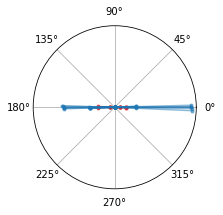

In [15]:
select = 0
scale = 10

mode_shape = new_mode[:,:,select]@R 
complex_plot_3D(mode_shape)
mode_dict = dict()

mode_dict["freq"] = a.nat_freq[select]
mode_dict["damp"] = a.nat_xi[select]*100
mode_dict["mcf"] = MCF(mode_shape.flatten())*100

mode_dict["animation_pts"] = mode_animation(mode_shape,scale,no_points = 60)
mode_dict["mesh"] = surf
mode_dict["or_pts"] = pts

mode_dict["scalars"] = True
mode_dict["fps"] = 30

view3D.add_modeshape(mode_dict,run_animation = True)